## Application: [[7, 1, 3]] Steane code

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Latex
from scipy import stats
from syqma.qec_simulator import QECSimulator

# number of physical qubits
n = 8

# define the qubits support for stabilisers and logical operators in the Steane code
steane_stabilisers = [[0, 1, 2, 3], [1, 2, 4, 5], [2, 3, 5, 6]]
steane_logicals = [[0, 1, 4], [0, 3, 6], [4, 5, 6], [0, 1, 2, 3, 4, 5, 6]]

# choose one logical representative
logical_qubits = steane_logicals[0]

Initialise one instance of the `QECSimulator` class and prepare the logical state |0>, and measure the ancilla and the Z stabilisers.

In [2]:
sim = QECSimulator(n=n)

# |0> logical state preparation
sim.h(0)
sim.pauli_error_1(0)
sim.h(4)
sim.pauli_error_1(4)
sim.h(6)
sim.pauli_error_1(6)
sim.cnot(0, 1)
sim.pauli_error_2((0, 1))
sim.cnot(4, 5)
sim.pauli_error_2((4, 5))
sim.cnot(6, 3)
sim.pauli_error_2((6, 3))
sim.cnot(4, 2)
sim.pauli_error_2((4, 2))
sim.cnot(6, 5)
sim.pauli_error_2((6, 5))
sim.cnot(0, 3)
sim.pauli_error_2((0, 3))
sim.cnot(4, 1)
sim.pauli_error_2((4, 1))
sim.cnot(3, 2)
sim.pauli_error_2((3, 2))

sim.cnot(1, 7)
sim.pauli_error_2((1, 7))
sim.cnot(3, 7)
sim.pauli_error_2((3, 7))
sim.cnot(5, 7)
sim.pauli_error_2((5, 7))

# projectively measure the ancilla
sim.measure(7)

# define and measure Z stabilisers virtually (no ancillas)
z_stabilisers = [("Z" * len(qubits), qubits) for qubits in steane_stabilisers]
sim.measure_stabilisers_virtually(z_stabilisers)

# measure Z logical operator in Z basis and store the solutions in the output
output_z = sim.measure_all(logical_qubits)

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ 🌲 Enumerating DFS Solutions...                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Contributing Terms 16 / 16


╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ ⚙️ Processing Valid DFS Solutions...                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Output()

 Stabiliser Simulation Summary  
╭────────────────────┬─────────╮
│ Field              │ Value   │
├────────────────────┼─────────┤
│ Contributing Terms │ 16 / 16 │
╰────────────────────┴─────────╯

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ 🌲 Enumerating DFS Solutions...                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Contributing Terms 16 / 16


╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ ⚙️ Processing Valid DFS Solutions...                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Output()

 Stabiliser Simulation Summary  
╭────────────────────┬─────────╮
│ Field              │ Value   │
├────────────────────┼─────────┤
│ Contributing Terms │ 16 / 16 │
╰────────────────────┴─────────╯

Initialise another instance of the `QECSimulator` class and prepare the logical state |+>, and measure the ancilla and the X stabilisers.

In [3]:
all_acceptance_probabilities = []
all_exp_val_z_free = []
all_exp_val_z_postselected = []
all_exp_val_z_corrected = []

# define the base physical error rates
all_p0 = np.logspace(-5, 0, 11)

for p0 in all_p0:
    # variance in the error distribution, 0 is depolarising channel
    std_dev_scale = 0.0

    # generate the error probabilities for the 1q and 2q Pauli channels
    p_base_1q = np.random.normal(p0 / 3, std_dev_scale * p0 / 3, 3)
    errors_1q = np.hstack((1 - p0, p_base_1q))
    p_base_2q = np.random.normal(p0 / 15, std_dev_scale * p0 / 15, 15)
    errors_2q = np.hstack((1 - p0, p_base_2q))

    # calculate the expectation values of the logical operators in the case of only postselecting on the ancilla
    exp_val_z_free = sim.postselected_expectation_value(errors_1q, errors_2q, measured_qubits=logical_qubits, measured_pauli_string="Z" * len(logical_qubits), postselected_indices=[0], output=output_z)
    
    # calculate the expectation values of the logical operators in the case of postselecting on the ancilla andall the stabilisers
    exp_val_z_postselected = sim.postselected_expectation_value(errors_1q, errors_2q, measured_qubits=logical_qubits, measured_pauli_string="Z" * len(logical_qubits), postselected_indices=list(range(len(z_stabilisers) + 1)), output=output_z)
    
    syndrome_probabilities_z = {}
    lut_z = {}
    
    # get the probabilities of all the syndromes
    syndrome_probabilities_z = sim.get_all_marginal_probabilities(errors_1q, errors_2q)
    
    # get the LUTs of expectation values based on syndromes
    lut_z = sim.lut_exp_vals_from_syndromes(("Z" * len(logical_qubits), logical_qubits), list(range(len(z_stabilisers) + 1)), errors_1q, errors_2q, output=output_z)
    
    # check that the sum of the probabilities of all the syndromes is 1.0
    assert np.isclose(sum(list(syndrome_probabilities_z.values())), 1.0)
    
    # calculate the expectation values of the logical operators by summing over all the syndrome-dependent expectation values
    exp_val_z_probabilities = sum([v * lut_z[k] if k[0] == 0 else 0 for k, v in syndrome_probabilities_z.items()]) / sum([v if k[0] == 0 else 0 for k, v in syndrome_probabilities_z.items()])
    
    # check that the free expectation values are the same as summing over all the syndrome-dependent expectation values with ancilla being 0
    assert np.isclose(exp_val_z_probabilities, exp_val_z_free)
    
    # calculate the expectation values of the logical operators after perfect error correction
    exp_val_z_corrected = sum([v * abs(lut_z[k]) for k, v in syndrome_probabilities_z.items()])
    
    all_exp_val_z_free.append(exp_val_z_free)
    all_exp_val_z_postselected.append(exp_val_z_postselected)
    all_exp_val_z_corrected.append(exp_val_z_corrected)
    
    acceptance_probability = syndrome_probabilities_z[tuple([0] * (len(z_stabilisers) + 1))]
    all_acceptance_probabilities.append(acceptance_probability)


╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ 🌲 Enumerating DFS Solutions...                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Contributing Terms 16 / 16


╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ ⚙️ Processing Valid DFS Solutions...                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Output()

 Stabiliser Simulation Summary  
╭────────────────────┬─────────╮
│ Field              │ Value   │
├────────────────────┼─────────┤
│ Contributing Terms │ 16 / 16 │
╰────────────────────┴─────────╯

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ 🌲 Enumerating DFS Solutions...                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Contributing Terms 16 / 16


╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ ⚙️ Processing Valid DFS Solutions...                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Output()

 Stabiliser Simulation Summary  
╭────────────────────┬─────────╮
│ Field              │ Value   │
├────────────────────┼─────────┤
│ Contributing Terms │ 16 / 16 │
╰────────────────────┴─────────╯

From expectation values, we need to calculate logical error rates, as well as convert the acceptance probabilities to discard probabilities. After that, we can fit the data to get the logical error rate scaling with physical error rate in log-log space.

In [4]:
all_exp_val_z_free = [float(v) for v in all_exp_val_z_free]
all_exp_val_z_postselected = [float(v) for v in all_exp_val_z_postselected]
all_exp_val_z_corrected = [float(v) for v in all_exp_val_z_corrected]
all_acceptance_probabilities = [float(v) for v in all_acceptance_probabilities]

all_ler_z_free = (1 - np.array(all_exp_val_z_free)) / 2
all_ler_z_postselected = (1 - np.array(all_exp_val_z_postselected)) / 2
all_ler_z_corrected = (1 - np.array(all_exp_val_z_corrected)) / 2
all_discard_probabilities = 1 - np.array(all_acceptance_probabilities)

fit_z_free = stats.linregress(np.log(all_p0), np.log(all_ler_z_free))
fit_z_postselected = stats.linregress(np.log(all_p0), np.log(all_ler_z_postselected))
fit_z_corrected = stats.linregress(np.log(all_p0), np.log(all_ler_z_corrected))
fit_discard = stats.linregress(np.log(all_p0), np.log(all_discard_probabilities))

Now we plot the obtained discard probabilities and logical error rates.

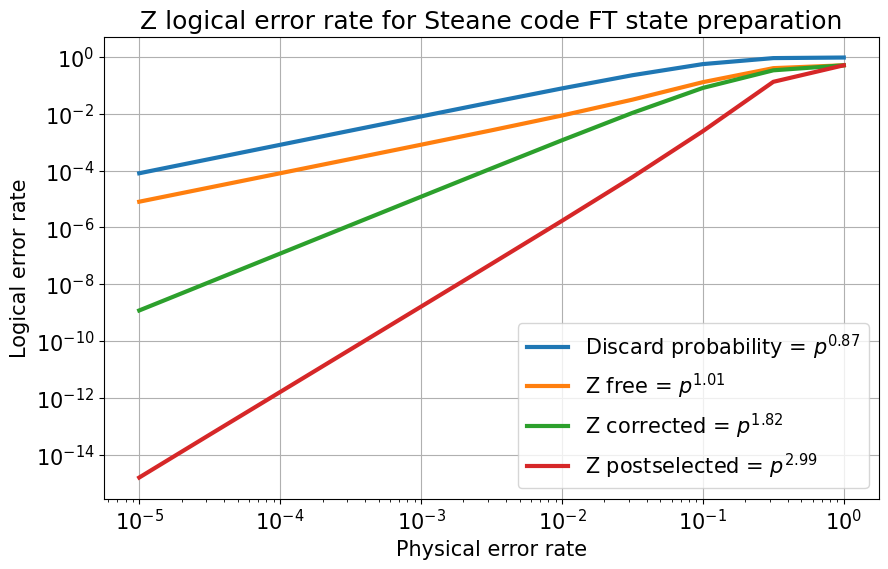

In [5]:
# default is 10
plt.rcParams.update({'font.size': 15})

colors = plt.get_cmap("tab10")
markers = ["o", "^", "s", "D", "X", "v"]
# markersize = 10
markersize = 0
# default is 2
linewidth = 3

fig = plt.figure(figsize=(10, 6))

plt.title(f"Z logical error rate for Steane code FT state preparation")
plt.plot(all_p0, all_discard_probabilities, linewidth=linewidth, marker=markers[3], markersize=markersize, markeredgecolor="black", color=colors(0), label=rf"Discard probability = $p^{{{fit_discard.slope:.2f}}}$")
plt.plot(all_p0, all_ler_z_free, linewidth=linewidth, marker=markers[0], markersize=markersize, markeredgecolor="black", color=colors(1), label=rf"Z free = $p^{{{fit_z_free.slope:.2f}}}$")
plt.plot(all_p0, all_ler_z_corrected, linewidth=linewidth, marker=markers[2], markersize=markersize, markeredgecolor="black", color=colors(2), label=rf"Z corrected = $p^{{{fit_z_corrected.slope:.2f}}}$")
plt.plot(all_p0, all_ler_z_postselected, linewidth=linewidth, marker=markers[1], markersize=markersize, markeredgecolor="black", color=colors(3), label=rf"Z postselected = $p^{{{fit_z_postselected.slope:.2f}}}$")

plt.xlabel("Physical error rate")
plt.ylabel("Logical error rate")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.grid()
plt.show()

Let us just measure the ancilla, but no stabilisers, so we have 1 symbolic measurement.

In [6]:
sim = QECSimulator(n)

# |0> logical state preparation
sim.h(0)
sim.pauli_error_1(0)
sim.h(4)
sim.pauli_error_1(4)
sim.h(6)
sim.pauli_error_1(6)
sim.cnot(0, 1)
sim.pauli_error_2((0, 1))
sim.cnot(4, 5)
sim.pauli_error_2((4, 5))
sim.cnot(6, 3)
sim.pauli_error_2((6, 3))
sim.cnot(4, 2)
sim.pauli_error_2((4, 2))
sim.cnot(6, 5)
sim.pauli_error_2((6, 5))
sim.cnot(0, 3)
sim.pauli_error_2((0, 3))
sim.cnot(4, 1)
sim.pauli_error_2((4, 1))
sim.cnot(3, 2)
sim.pauli_error_2((3, 2))

sim.cnot(1, 7)
sim.pauli_error_2((1, 7))
sim.cnot(3, 7)
sim.pauli_error_2((3, 7))
sim.cnot(5, 7)
sim.pauli_error_2((5, 7))

# projectively measure the ancilla
sim.measure(7)

# measure Z logical operator in Z basis and store the solutions in the output
output_z = sim.measure_all(logical_qubits)

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ 🌲 Enumerating DFS Solutions...                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Contributing Terms 2 / 2


╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ ⚙️ Processing Valid DFS Solutions...                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Output()

Stabiliser Simulation Summary 
╭────────────────────┬───────╮
│ Field              │ Value │
├────────────────────┼───────┤
│ Contributing Terms │ 2 / 2 │
╰────────────────────┴───────╯

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ 🌲 Enumerating DFS Solutions...                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Contributing Terms 2 / 2


╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ ⚙️ Processing Valid DFS Solutions...                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Output()

Stabiliser Simulation Summary 
╭────────────────────┬───────╮
│ Field              │ Value │
├────────────────────┼───────┤
│ Contributing Terms │ 2 / 2 │
╰────────────────────┴───────╯

Different levels of symbolic printing:
1. Errors have different probabilities within a Pauli channel, and are different between different channels.
2. Errors have different probabilities within a Pauli channel, and are the same between different channels. (no variability across qubits)
3. Errors have the same probabilities within a Pauli channel (depolarising noise), and are different between different channels. 
4. Errors have the same probabilities within a Pauli channel (depolarising noise), and are the same between different channels. (no variability across qubits, no variability between channels)

For more seamless printing, we use the substitution *$\lambda$ = 1 - 2 * p'*. As *p'* was close 0, now each *$\lambda$* is close to 1.

N.B. We are just showing the numerator of the expression for simplicity, but the denominator can be equally complicated.


In [7]:
p0 = 1e-5
std_dev_scale = 0.0

p_base_1q = np.random.normal(p0 / 3, std_dev_scale * p0 / 3, 3)
errors_1q = np.hstack((1 - p0, p_base_1q))
p_base_2q = np.random.normal(p0 / 15, std_dev_scale * p0 / 15, 15)
errors_2q = np.hstack((1 - p0, p_base_2q))

measurement_results = np.zeros(sim.n_m)
measurement_results = np.ones(sim.n_m)
thetas = np.zeros(sim.n_magic)

errors_1q = None
errors_2q = None
measurement_results = None
thetas = None

symbolic_expressions = output_z.print_symbolic_expression(errors_1q=errors_1q, errors_2q=errors_2q, measurement_results=measurement_results, thetas=thetas)
for d in range(2):
    for g in range(2):
        display(Latex(rf"$$ {symbolic_expressions[d][g]} $$"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

We can see the coefficient of each term in the Taylor expansion of the uncorrected EV as a function of the physical error rate $p$, as well as the contribution of each order to the expectation value for a fixed value of the physical error rate $p = 10^{-5}$.


In [8]:
measurement_results = None

sim.evaluate_expectation_value_taylor(
    output_z,
    measurement_results=measurement_results,
    thetas=thetas,
    p=1e-5
)

A[0]: 1.0 1.0 1.0

A[1] p^1: -4.266666666666667 -4.266666666666667e-05
A[2] p^2: -25.031111111111112 -2.503111111111112e-09
A[3] p^3: -231.39871604938273 -2.313987160493828e-13
A[4] p^4: -2529.959295473251 -2.5299592954732523e-17
A[5] p^5: -30224.580383253768 -3.022458038325378e-21
A[6] p^6: -381501.3701708476 -3.815013701708477e-25

EV0: 1.0
EV1: 0.9999573333333334
EV2: 0.9999573308302222
EV3: 0.9999573308299908
EV4: 0.9999573308299908
EV5: 0.9999573308299908
EV6: 0.9999573308299908

LER[1]: 2.1333333333333335e-05
LER_coefficient[1]: 2.1333333333333333
LER[2]: 1.251555555555556e-09
LER_coefficient[2]: 12.515555555555556
LER[3]: 1.156993580246914e-13
LER_coefficient[3]: 115.69935802469136
LER[4]: 1.2649796477366261e-17
LER_coefficient[4]: 1264.9796477366256
LER[5]: 1.511229019162689e-21
LER_coefficient[5]: 15112.290191626884
LER[6]: 1.9075068508542386e-25
LER_coefficient[6]: 190750.6850854238

Time taken by taylor_coeffs: 0.0004439353942871094s


Time taylor coeffs: 0.00044989585876464

If we now also measure the 3 Z stabilisers, we have 4 symbolic measurements.

In [9]:
sim.measure_stabilisers_virtually(z_stabilisers)

output_z_postselected = sim.measure_all(logical_qubits)

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ 🌲 Enumerating DFS Solutions...                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Contributing Terms 16 / 16


╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ ⚙️ Processing Valid DFS Solutions...                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Output()

 Stabiliser Simulation Summary  
╭────────────────────┬─────────╮
│ Field              │ Value   │
├────────────────────┼─────────┤
│ Contributing Terms │ 16 / 16 │
╰────────────────────┴─────────╯

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ 🌲 Enumerating DFS Solutions...                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Contributing Terms 16 / 16


╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ ⚙️ Processing Valid DFS Solutions...                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Output()

 Stabiliser Simulation Summary  
╭────────────────────┬─────────╮
│ Field              │ Value   │
├────────────────────┼─────────┤
│ Contributing Terms │ 16 / 16 │
╰────────────────────┴─────────╯

In [10]:
symbolic_expressions = output_z_postselected.print_symbolic_expression(errors_1q=errors_1q, errors_2q=errors_2q, measurement_results=None, thetas=thetas)
for d in range(2):
    for g in range(2):
        display(Latex(rf"$$ {symbolic_expressions[d][g]} $$"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Similar to before, we can see the coefficient of each term in the Taylor expansion of the postselected EV as a function of the physical error rate $p$, as well as the contribution of each order to the expectation value for a fixed value of the physical error rate $p = 10^{-5}$.


In [11]:
measurement_results = np.zeros(sim.n_m)

sim.evaluate_expectation_value_taylor(
    output_z_postselected,
    measurement_results=measurement_results,
    thetas=thetas,
    p=1e-5
)

A[0]: 16.0 16.0 1.0

A[1] p^1: 0.0 0.0
A[2] p^2: 0.0 0.0
A[3] p^3: -3.261629629629624 -3.261629629629625e-15
A[4] p^4: -85.96543209876518 -8.596543209876521e-19
A[5] p^5: -1710.5219634567911 -1.7105219634567917e-22
A[6] p^6: -30737.553159842675 -3.073755315984269e-26

EV0: 1.0
EV1: 1.0
EV2: 1.0
EV3: 0.9999999999999968
EV4: 0.9999999999999968
EV5: 0.9999999999999968
EV6: 0.9999999999999968

LER[3]: 1.6308148148148124e-15
LER_coefficient[3]: 1.630814814814812
LER[4]: 4.2982716049382607e-19
LER_coefficient[4]: 42.98271604938259
LER[5]: 8.552609817283958e-23
LER_coefficient[5]: 855.2609817283956
LER[6]: 1.5368776579921345e-26
LER_coefficient[6]: 15368.776579921338

Time taken by taylor_coeffs: 0.001271963119506836s


Time taylor coeffs: 0.0012769699096679688s
